# Notebook 1 — Chain Ladder agrégé : modélisation de la structure par terme des remboursements anticipés

## Contexte et problématique

L'objectif de ce notebook est de modéliser, au niveau cohorte, la structure par terme des taux de remboursement anticipé (ER) observés sur un portefeuille de prêts immobiliers. La méthode Chain Ladder classique est ici adaptée à des données en coupe transversale : chaque contrat n'est observé qu'à une seule date, ce qui interdit le suivi longitudinal individuel.

**Définitions centrales**

- **Cohorte** : groupe de contrats partageant la même période d'origination (trimestre).
- **Capital initial** : `MTECH × B_MAT`, utilisé comme dénominateur fixe pour toute la cohorte.
- **ER cumulé** à l'âge $t$ pour la cohorte $c$ :

$$ER_{cumule}(c,t) = \frac{\sum_{i \in c} RA_i(t)}{\sum_{i \in c} Capital\_initial_i}$$

Le dénominateur est **fixe** (capital initial, pas le CRD courant). Ce choix évite un biais de composition : des prêts qui ont déjà remboursé partiellement auraient un CRD résiduel plus faible, ce qui gonflerait artificiellement le taux.

**Note sur la formule du professeur** : le sujet mentionne également `CRD = MTECH × B_RESMAT - RA` et `ER = RA / CRD`. Cette définition utilise un dénominateur *courant* (CRD résiduel), différent de l'approche cohorte agrégée retenue ici. Les deux définitions coexistent dans la base sous les colonnes `CRD`, `EAD` et `ER_obs`. Dans ce notebook, on travaille exclusivement avec `Capital_initial` comme dénominateur.

## 1. Imports

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliothèques chargées")

Bibliothèques chargées


## 2. Chargement et premiers contrôles

La base contient 63 585 contrats (un par ligne), couvrant les originations de 2006 à 2023. Les variables clés utilisées dans ce notebook sont :

| Variable | Rôle |
|---|---|
| `Capital_initial` | `MTECH × B_MAT` — dénominateur fixe de l'ER |
| `RA` | Remboursement anticipé observé |
| `AGE_PRET` | Âge du prêt en mois à la date d'observation |
| `Cohorte` | Trimestre d'origination (format `YYYYQQ`) |
| `EAD` | Capital restant dû courant (utilisé pour les contrôles) |
| `B_RESMAT` | Nombre d'échéances restantes |
| `NB_ECH` | Durée initiale du prêt en échéances |

**Point de vigilance sur B_RESMAT** : le ratio moyen `B_RESMAT / NB_ECH` est de 0,61, ce qui est cohérent avec un portefeuille en vie composé majoritairement de prêts à mi-parcours. `B_RESMAT` et `HORIZON_RES` semblent être la même variable (ratio = 1,0 après vérification).

In [117]:
df = pd.read_csv("Export_ER_Agrege.csv", sep=";")
df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

print(f"Dimensions : {df.shape}")
print(f"Période couverte : {df['Date_origination'].min().date()} -> {df['Date_origination'].max().date()}")
print(f"Nombre de prêts uniques : {df['ID'].nunique()}")
print(f"\nColonnes : {df.columns.tolist()}")

Dimensions : (63585, 25)
Période couverte : 2006-01-11 -> 2023-12-01
Nombre de prêts uniques : 63585

Colonnes : ['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET', 'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER', 'Capital_initial', 'Date_origination', 'Cohorte']


In [118]:
prets_par_annee = (
    df.dropna(subset=["Date_origination"])
    .assign(annee=df["Date_origination"].dt.year)
    .groupby("annee")["ID"]
    .nunique()
    .sort_index()
)
print(prets_par_annee)

annee
2006        1
2007        8
2008        8
2009       13
2010       39
2011      220
2012      385
2013      634
2014     1029
2015     2224
2016     4848
2017     8825
2018    13005
2019    11995
2020     8738
2021     6943
2022     3948
2023      722
Name: ID, dtype: int64


La distribution montre une montée en charge progressive jusqu'à 2018–2019 (pic autour de 13 000 prêts/an), suivie d'un repli lié à l'arrêt de la production ou à une fenêtre d'observation tronquée. Les millésimes 2006–2010 sont anecdotiques (moins de 50 contrats) et apporteront peu d'information au triangle.

### Contrôle : B_RESMAT vs NB_ECH

Avant de construire le triangle, on vérifie la cohérence des variables de durée.

In [119]:
print("Statistiques B_RESMAT :")
print(df['B_RESMAT'].describe())
print("\nStatistiques NB_ECH :")
print(df['NB_ECH'].describe())
print(f"\nRatio moyen B_RESMAT / NB_ECH : {(df['B_RESMAT'] / df['NB_ECH']).mean():.2f}")

Statistiques B_RESMAT :
count    63585.000000
mean        44.314492
std         30.996450
min          1.000000
25%         22.000000
50%         38.000000
75%         57.000000
max        167.000000
Name: B_RESMAT, dtype: float64

Statistiques NB_ECH :
count    63585.000000
mean        69.535346
std         33.382598
min          2.000000
25%         48.000000
50%         60.000000
75%         79.000000
max        170.000000
Name: NB_ECH, dtype: float64

Ratio moyen B_RESMAT / NB_ECH : 0.61


# Algorithme

In [120]:
import numpy as np
import pandas as pd

def eval_config(df, age_bin_months=6, H_bins=16, min_cell=20):
    """
    age_bin_months: taille des colonnes en mois (1,3,6,12)
    H_bins: horizon max en nombre de bins (ex: 16 semestres si age_bin_months=6)
    min_cell: seuil volume souhaité par cellule
    """
    d = df.copy()
    d["AGE_BIN"] = (d["AGE_PRET"] // age_bin_months).astype(int)

    # volume par cellule
    vol = d.pivot_table(index="Cohorte", columns="AGE_BIN", values="ER_obs", aggfunc="count")

    # garder cohortes "matures" (atteignent H_bins)
    max_age = d.groupby("Cohorte")["AGE_BIN"].max()
    keep_coh = max_age[max_age >= H_bins].index
    if len(keep_coh) < 8:   # contrainte : au moins quelques cohortes
        return None

    vol = vol.loc[keep_coh, vol.columns <= H_bins]

    # stats volumes (uniquement cellules non vides)
    v = vol.values
    nonzero = v[~np.isnan(v)]
    if nonzero.size == 0:
        return None

    fill = np.mean(~np.isnan(v))                      # remplissage
    mean_v = np.nanmean(v)                            # volume moyen cellule
    p10 = np.nanpercentile(nonzero, 10)               # robustesse bas de distrib
    share_ge_min = np.nanmean(v >= min_cell)          # % cellules "solides"

    # score (pondérations à ajuster)
    score = 0.45 * p10 + 0.35 * mean_v + 0.20 * (100 * share_ge_min)
    return {
        "age_bin_months": age_bin_months,
        "H_bins": H_bins,
        "n_cohortes": len(keep_coh),
        "fill": fill,
        "mean_v": mean_v,
        "p10": p10,
        "share_ge_min": share_ge_min,
        "score": score
    }

def find_best_organization(df):
    results = []
    for age_bin_months in [1, 3, 6, 12]:
        # horizons raisonnables selon binning (ex: 10 ans)
        # 10 ans = 120 mois -> en bins = 120 / age_bin_months
        max_bins_10y = int(120 // age_bin_months)
        # on teste plusieurs H (plus H est grand, plus tu perds des cohortes)
        for H_bins in [int(max_bins_10y*0.5), int(max_bins_10y*0.6), int(max_bins_10y*0.7), int(max_bins_10y*0.8)]:
            out = eval_config(df, age_bin_months=age_bin_months, H_bins=H_bins, min_cell=20)
            if out is not None:
                results.append(out)
    res = pd.DataFrame(results).sort_values("score", ascending=False)
    return res

# usage:
res = find_best_organization(df_recent)
print(res.head(10))
best = res.iloc[0].to_dict()
print("\nBEST:", best)

    age_bin_months  H_bins  n_cohortes      fill      mean_v   p10  \
12              12       5          24  0.583333  344.714286  53.3   
8                6      10          24  0.500000  213.886364  46.0   
13              12       6          20  0.571429  210.150000  37.8   
9                6      12          20  0.500000  126.607692  24.0   
4                3      20          24  0.458333  120.281385  29.0   
14              12       7          16  0.562500  116.611111  25.0   
15              12       8          12  0.555556   63.083333  17.7   
10               6      14          16  0.500000   68.558333  16.0   
5                3      24          20  0.460000   70.560870  13.9   
0                1      60          24  0.430328   43.573016  12.0   

    share_ge_min       score  
12      0.562500  155.885000  
8       0.484848  105.257197  
13      0.550000  101.562500  
9       0.473077   64.574231  
4       0.442460   63.997691  
14      0.531250   62.688889  
15      0.46

In [121]:
import numpy as np
import pandas as pd

def make_cohort_period(cohorte_series, target_freq):
    """
    cohorte_series : ex "2013Q1"
    target_freq    : "Q", "2Q", "A"
    """
    q = pd.PeriodIndex(cohorte_series.astype(str), freq="Q")
    # On passe par timestamp pour éviter les bizarreries d'asfreq selon versions pandas
    ts = q.to_timestamp(how="start")
    return ts.to_period(target_freq)

def eval_config(df, cohort_freq="Q", age_bin_months=6, H_bins=16, min_cell=20, min_coh=8):
    d = df.copy()

    # 1) cohorte regroupée
    d["COH"] = make_cohort_period(d["Cohorte"], cohort_freq).astype(str)

    # 2) âge regroupé
    d["AGE_BIN"] = (d["AGE_PRET"] // age_bin_months).astype(int)

    # 3) triangle volume (nb obs/contrats)
    vol = d.pivot_table(index="COH", columns="AGE_BIN", values="ER_obs", aggfunc="count")

    # 4) garder cohortes "matures" (atteignent H)
    max_age = d.groupby("COH")["AGE_BIN"].max()
    keep = max_age[max_age >= H_bins].index
    if len(keep) < min_coh:
        return None

    vol = vol.loc[keep, vol.columns <= H_bins]

    v = vol.values
    nonnan = v[~np.isnan(v)]
    if nonnan.size == 0:
        return None

    # métriques
    fill = np.mean(~np.isnan(v))
    mean_v = np.nanmean(v)
    p10 = np.nanpercentile(nonnan, 10)
    share_ge = np.nanmean(v >= min_cell)

    # score (oriente "cellules solides" + volume)
    score = 0.50 * p10 + 0.30 * mean_v + 0.20 * (100 * share_ge)

    return {
        "cohort_freq": cohort_freq,
        "age_bin_months": age_bin_months,
        "H_bins": H_bins,
        "n_cohortes": len(keep),
        "fill": fill,
        "mean_cell": mean_v,
        "p10_cell": p10,
        "share_cell_ge_min": share_ge,
        "score": score
    }

def find_best_organization(df):
    results = []
    cohort_freqs = ["Q", "2Q", "A"]
    age_bins = [1, 3, 6, 12]

    for cf in cohort_freqs:
        for ab in age_bins:
            # Horizon max "raisonnable" ~10 ans = 120 mois
            max_bins_10y = int(120 // ab)
            # on teste plusieurs horizons (plus H est grand, plus tu perds des cohortes)
            for H in sorted(set([
                int(max_bins_10y*0.5),
                int(max_bins_10y*0.6),
                int(max_bins_10y*0.7),
                int(max_bins_10y*0.8),
            ])):
                out = eval_config(df, cohort_freq=cf, age_bin_months=ab, H_bins=H, min_cell=20, min_coh=6)
                if out is not None:
                    results.append(out)

    res = pd.DataFrame(results).sort_values("score", ascending=False)
    return res

# === usage ===
res = find_best_organization(df_recent)
display(res.head(15))

best = res.iloc[0].to_dict()
print("\nBEST CONFIG:", best)

,cohort_freq,age_bin_months,H_bins,n_cohortes,fill,mean_cell,p10_cell,share_cell_ge_min,score
35,A,12,5,6,0.583333,1378.857143,308.0,0.583333,579.323810
34,A,6,10,6,0.545455,784.250000,188.0,0.545455,340.184091
33,A,3,20,6,0.523810,420.984848,89.5,0.515873,181.362915
28,2Q,12,5,24,0.583333,344.714286,53.3,0.562500,141.314286
12,Q,12,5,24,0.583333,344.714286,53.3,0.562500,141.314286
8,Q,6,10,24,0.500000,213.886364,46.0,0.484848,96.862879
24,2Q,6,10,24,0.500000,213.886364,46.0,0.484848,96.862879
29,2Q,12,6,20,0.571429,210.150000,37.8,0.550000,92.945000
13,Q,12,6,20,0.571429,210.150000,37.8,0.550000,92.945000
32,A,1,60,6,0.491803,152.505556,38.9,0.480874,74.819153



BEST CONFIG: {'cohort_freq': 'A', 'age_bin_months': 12, 'H_bins': 5, 'n_cohortes': 6, 'fill': 0.5833333333333334, 'mean_cell': 1378.857142857143, 'p10_cell': 308.0, 'share_cell_ge_min': 0.5833333333333334, 'score': 579.3238095238095}


Le ratio moyen 0,61 confirme que les prêts sont en moyenne à 61 % de leur durée écoulée. `B_RESMAT` (échéances restantes) et `NB_ECH` (durée initiale) sont bien dans la même unité (échéances mensuelles).

## 3. Filtrage sur les 10 dernières années

Pour obtenir un triangle suffisamment dense, on ne retient que les cohortes des 10 dernières années (44 trimestres glissants depuis la cohorte la plus récente). Cela revient à travailler sur 2013Q1 – 2023Q4, ce qui couvre 98,9 % des observations.

In [122]:
q = pd.PeriodIndex(df["Cohorte"].astype(str), freq="Q")
cutoff = q.max() - 43  # 44 trimestres = 11 ans (cohorte max incluse)

df_recent = df[q >= cutoff].copy()
print(f"Données filtrées (10 ans) : {len(df_recent)} contrats ({len(df_recent)/len(df):.1%})")
print(f"Période couverte : {df_recent['Cohorte'].min()} à {df_recent['Cohorte'].max()}")
print(f"Nombre de cohortes : {df_recent['Cohorte'].nunique()}")

Données filtrées (10 ans) : 62911 contrats (98.9%)
Période couverte : 2013Q1 à 2023Q4
Nombre de cohortes : 44


## 4. Construction du triangle agrégé

Le triangle est une matrice *(cohorte × âge)* dont chaque cellule représente l'ER cumulé agrégé. La construction se fait en trois étapes :

1. Calcul du **capital initial total** par cohorte (dénominateur fixe).
2. Agrégation des **RA marginaux** par *(cohorte, âge)*.
3. **Cumul** des RA marginaux par cohorte, puis division par le capital initial pour obtenir l'ER cumulé.

Les ER cumulés sont bornés à 0 par le bas (on évite des valeurs négatives liées à des corrections comptables dans la base).

In [123]:
# 1) EAD initial par cohorte
ead_initial = df_recent.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")
print(f"EAD initial total : {ead_initial.sum():,.0f} EUR")
print(f"EAD initial moyen par cohorte : {ead_initial.mean():,.0f} EUR")

# 2) RA marginal par (cohorte, age)
ra_marg = (
    df_recent.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)

# 3) RA cumulé puis ER cumulé
ra_marg["RA_cum"] = ra_marg.groupby("Cohorte")["RA"].cumsum()
ra_marg["ER_cumule"] = (ra_marg["RA_cum"] / ra_marg["EAD_initial"]).clip(lower=0)

# 4) Triangle cumulé
triangle_cumule = ra_marg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()

# Volume (nb observations par cellule)
triangle_volume = df_recent.pivot_table(
    index='Cohorte', columns='AGE_PRET', values='ER_obs', aggfunc='count'
)

EAD initial total : 1,203,674,236 EUR
EAD initial moyen par cohorte : 27,356,233 EUR


## 5. Contrôles qualité sur le triangle

Avant de calculer les facteurs Chain Ladder, il est indispensable de vérifier :
- La cohérence des volumes par cohorte et par cellule.
- L'absence de valeurs aberrantes (ER cumulé > 1, baisses inexpliquées).
- La cohérence entre les RA totaux et les EAD initiaux.

### 5.1 Vérification de la monotonie

L'ER cumulé doit être **non décroissant** par construction (le cumul de RA marginaux positifs ne peut pas baisser). Des baisses indiqueraient des RA négatifs (corrections comptables ou erreurs de données).

In [124]:
print("=== CHECK COHORTES / AGES ===")
print("cohorte min/max :", df_recent["Cohorte"].min(), "->", df_recent["Cohorte"].max())
print("nb cohortes :", df_recent["Cohorte"].nunique())
print("age min/max :", df_recent["AGE_PRET"].min(), "->", df_recent["AGE_PRET"].max())

print("\n=== CHECK EAD INITIAL ===")
ead_stats = ead_initial.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])
print(ead_stats)
print("\n5 plus petites cohortes (EAD) :")
print(ead_initial.sort_values().head(5))

print("\n=== CHECK RA vs EAD (par cohorte) ===")
ra_tot = df_recent.groupby("Cohorte")["RA"].sum()
ratio_ra_ead = (ra_tot / ead_initial).sort_values(ascending=False)
print("Top 10 RA_total / EAD_initial :")
print(ratio_ra_ead.head(10))
print("Bottom 10 RA_total / EAD_initial :")
print(ratio_ra_ead.tail(10))

print("\n=== CHECK MONOTONIE ===")
diffs = triangle_cumule.diff(axis=1)
min_drop = diffs.min(axis=1)
print("Pire baisse (toutes cohortes) :", np.nanmin(min_drop.values))
print("Cohortes avec baisse < -1e-6 :")
print(min_drop[min_drop < -1e-6].sort_values().head(10))

print("\n=== SUGGESTION MASQUE VOLUME ===")
for thr in [2, 5, 10, 20, 50]:
    filled = (~triangle_cumule.mask(triangle_volume < thr).isna()).sum().sum()
    total = triangle_cumule.size
    print(f"seuil n<{thr:>2} -> remplissage {filled/total:.1%}")

=== CHECK COHORTES / AGES ===
cohorte min/max : 2013Q1 -> 2023Q4
nb cohortes : 44
age min/max : 0.0 -> 131.0

=== CHECK EAD INITIAL ===
count    4.400000e+01
mean     2.735623e+07
std      1.896054e+07
min      1.914997e+05
1%       6.127218e+05
5%       3.685576e+06
10%      5.617989e+06
25%      9.897225e+06
50%      2.344474e+07
75%      4.260178e+07
90%      5.580136e+07
95%      5.939859e+07
99%      6.029236e+07
max      6.071318e+07
Name: EAD_initial, dtype: float64

5 plus petites cohortes (EAD) :
Cohorte
2023Q4     191499.70
2023Q3    1171085.97
2023Q2    3502338.28
2013Q1    4723925.39
2023Q1    5462698.00
Name: EAD_initial, dtype: float64

=== CHECK RA vs EAD (par cohorte) ===
Top 10 RA_total / EAD_initial :
Cohorte
2023Q3    0.657000
2022Q2    0.622157
2022Q4    0.620085
2023Q1    0.617204
2022Q3    0.615712
2021Q4    0.609175
2022Q1    0.609133
2021Q3    0.595108
2021Q2    0.591735
2023Q2    0.590834
dtype: float64
Bottom 10 RA_total / EAD_initial :
Cohorte
2015Q4    0.281

**Interprétation des contrôles**

- **RA / EAD élevés sur les cohortes récentes (2021–2023)** : les ratios RA/EAD atteignent 0,62–0,66 sur ces cohortes. Ce niveau élevé peut s'expliquer par le contexte de remontée des taux en 2022–2023, qui a fortement incité les emprunteurs à renégocier ou rembourser par anticipation. Il convient cependant de le surveiller : un ER cumulé qui dépasse 1 serait incohérent.

- **RA / EAD faibles sur les vieilles cohortes (2013–2015)** : ces cohortes ont une observation partielle (seuls les prêts encore actifs à la date d'extraction sont présents). Les prêts déjà remboursés ou renégociés ont disparu de la base, ce qui sous-estime mécaniquement les RA totaux observés pour ces cohortes.

- **Baisses de monotonie** : si des baisses > 1e-6 sont détectées, elles proviennent de RA négatifs dans la base (corrections). Elles sont marginales et seront absorbées par le clip à 0.

- **Choix du seuil de volume** : un seuil de 30 observations par cellule sera utilisé pour masquer les cellules instables (voir ci-dessous).

### pourcents

In [125]:
# Remplissage brut (avant masque volume)
filled = triangle_cumule.notna().sum().sum()
total  = triangle_cumule.size
print(f"Remplissage triangle (brut) : {filled}/{total} = {filled/total:.1%}")

# Remplissage après un seuil de volume (ex: thr=20)
thr = 20
tri_masked = triangle_cumule.mask(triangle_volume < thr)
filled_m = tri_masked.notna().sum().sum()
print(f"Remplissage triangle (n>= {thr}) : {filled_m}/{total} = {filled_m/total:.1%}")

Remplissage triangle (brut) : 2036/5632 = 36.2%
Remplissage triangle (n>= 20) : 990/5632 = 17.6%


### 5.2 Contrats suspects : anciens prêts avec CRD élevé et RA nul

On repère les prêts avec une date d'origination ancienne (avant 2014), un âge proche de la durée initiale, mais un CRD encore substantiel et un RA nul. Ces profils peuvent correspondre à des prêts restructurés, des erreurs de saisie ou des contrats dont la vie contractuelle a été prolongée.

In [126]:
sus = df[
    (df["Date_origination"] < "2014-01-01") &
    (df["AGE_PRET"] > 0.8 * df["NB_ECH"]) &
    (df["CRD"] > 0) &
    (df["RA"].fillna(0) == 0)
]
print(f"Nombre de contrats suspects : {len(sus)}")
sus[["ID","Date_origination","NB_ECH","AGE_PRET","B_RESMAT","CRD","EAD","RA"]].head(15)

Nombre de contrats suspects : 41


,ID,Date_origination,NB_ECH,AGE_PRET,B_RESMAT,CRD,EAD,RA
509,a000817,2007-05-04,9,142.0,3.0,1013.25,0.00,0.0
1693,a002830,2013-11-29,32,63.0,10.0,3927.50,3361.68,0.0
1892,a003127,2007-06-04,17,142.0,2.0,537.84,110.96,0.0
2833,a004901,2010-04-17,84,108.0,49.0,11427.29,8422.36,0.0
3330,a005613,2010-09-14,102,103.0,22.0,3508.56,3067.51,0.0
4435,a007290,2012-09-04,63,80.0,41.0,7286.93,5911.47,0.0
4971,a008113,2009-05-23,37,120.0,5.0,2040.15,0.00,0.0
7480,a012040,2013-12-29,9,66.0,7.0,2943.36,2386.21,0.0
8995,a014352,2012-04-08,85,88.0,37.0,7090.31,5647.44,0.0
9233,a014719,2007-05-05,32,148.0,13.0,5850.00,5241.82,0.0


Ces profils peuvent être laissés dans la base : ils contribuent au capital initial de leur cohorte avec un RA nul, ce qui est correct (ils n'ont pas fait de remboursement anticipé). Leur présence ne biaise pas l'ER cumulé.

## 6. Triangle filtré — seuil minimum de 20 contrats par cohorte

On élimine la cohorte 2023Q4 qui ne compte pas assez de contrats pour produire des estimations stables. Le triangle résultant couvre 43 cohortes.

In [127]:
n_coh = df_recent.groupby("Cohorte").size()
keep_coh = n_coh[n_coh >= 20].index
print(f"Cohortes gardées : {len(keep_coh)} / {n_coh.size}")

df_stable = df_recent[df_recent["Cohorte"].isin(keep_coh)].copy()

ead_initial_s = df_stable.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

ra_marg_s = (
    df_stable.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial_s.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)
ra_marg_s["RA_cum"] = ra_marg_s.groupby("Cohorte")["RA"].cumsum()
ra_marg_s["ER_cumule"] = (ra_marg_s["RA_cum"] / ra_marg_s["EAD_initial"]).clip(lower=0)

triangle_cumule_s = ra_marg_s.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()
triangle_volume_s = df_stable.pivot_table(
    index="Cohorte", columns="AGE_PRET", values="ER_obs", aggfunc="count"
)

Cohortes gardées : 43 / 44


## 7. Visualisation du triangle et de la courbe globale

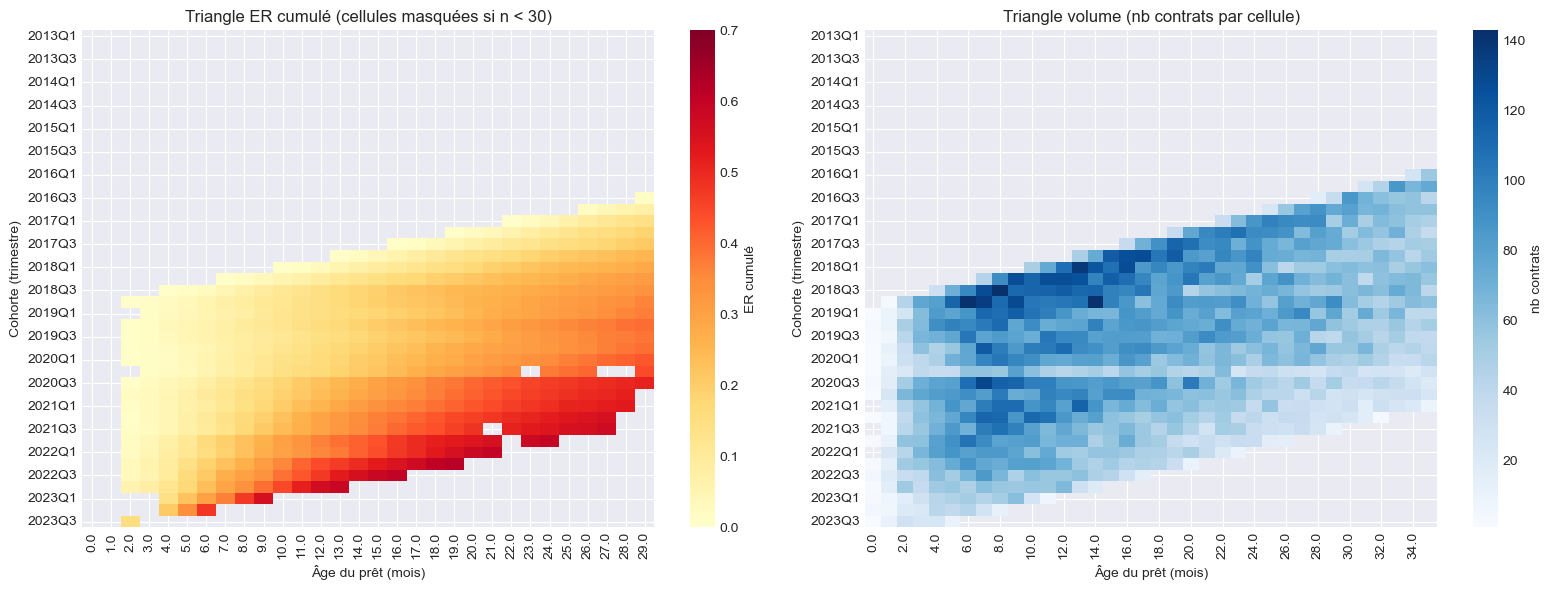

In [128]:
thr_cell = 30
tri_plot = triangle_cumule_s.mask(triangle_volume_s < thr_cell)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(tri_plot.iloc[:, :30], cmap="YlOrRd", vmin=0, vmax=0.7,
            cbar_kws={"label": "ER cumulé"}, ax=ax[0])
ax[0].set_title(f"Triangle ER cumulé (cellules masquées si n < {thr_cell})")
ax[0].set_xlabel("Âge du prêt (mois)")
ax[0].set_ylabel("Cohorte (trimestre)")

sns.heatmap(triangle_volume_s.mask(triangle_volume_s < 1).iloc[:, :36], cmap="Blues",
            cbar_kws={"label": "nb contrats"}, ax=ax[1])
ax[1].set_title("Triangle volume (nb contrats par cellule)")
ax[1].set_xlabel("Âge du prêt (mois)")
ax[1].set_ylabel("Cohorte (trimestre)")

plt.tight_layout()
plt.show()

Le triangle présente la structure attendue : les cohortes les plus anciennes (en haut) ont des observations sur tous les âges, tandis que les cohortes récentes (en bas) n'ont que quelques mois d'historique. La diagonale vide correspond aux cellules non encore atteintes.

On observe que l'ER cumulé croît progressivement avec l'âge du prêt, en atteignant des niveaux autour de 0,4–0,7 pour les cohortes les plus matures. Les cohortes 2021–2022 montrent des ER déjà élevés à des âges courts, reflétant le contexte de remontée des taux.

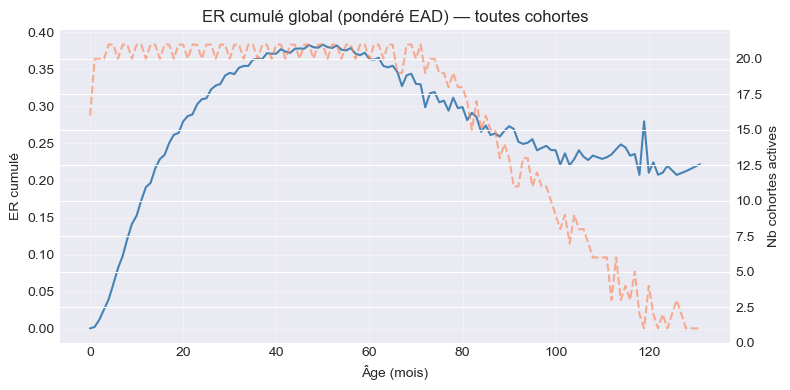

ER cumulé moyen observé : 0.2758


In [129]:
# Courbe globale pondérée par EAD
curve = ra_marg_s.groupby("AGE_PRET").agg(
    RA_cum_tot=("RA_cum", "sum"),
    EAD_tot=("EAD_initial", "sum")
).sort_index()
curve["ER_cum_pond"] = curve["RA_cum_tot"] / curve["EAD_tot"]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(curve.index, curve["ER_cum_pond"], color="steelblue")
ax1.set_title("ER cumulé global (pondéré EAD) — toutes cohortes")
ax1.set_xlabel("Âge (mois)")
ax1.set_ylabel("ER cumulé")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
active = ra_marg_s.groupby("AGE_PRET")["Cohorte"].nunique().sort_index()
ax2.plot(active.index, active.values, linestyle="--", color="coral", alpha=0.6)
ax2.set_ylabel("Nb cohortes actives")

plt.tight_layout()
plt.show()

print(f"ER cumulé moyen observé : {curve['ER_cum_pond'].dropna().mean():.4f}")


**Lecture de la courbe globale**

La courbe pondérée par EAD monte régulièrement sur les 36 premiers mois puis se stabilise à partir de 40–50 mois. La baisse observée après 80 mois s'explique par un **biais de survie** : seules les cohortes anciennes (peu nombreuses) contribuent à ces âges, et leur EAD est faible. Ce phénomène est bien visible sur le graphique secondaire (nombre de cohortes actives chute brutalement après 40 mois).

**Conséquence pratique** : pour les projections Chain Ladder, on se limitera à un horizon de 36 mois (`MAX_AGE = 36`), là où le nombre de cohortes actives est encore suffisant pour calculer des facteurs stables.

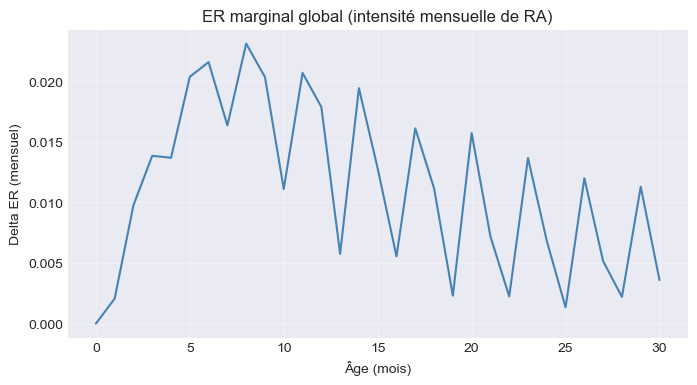

In [130]:
# ER marginal (intensité mensuelle de RA)
er_marg = curve["ER_cum_pond"].diff().fillna(0)
er_marg.loc[er_marg.index <= 30].plot(figsize=(8, 4), color="steelblue")
plt.title("ER marginal global (intensité mensuelle de RA)")
plt.xlabel("Âge (mois)")
plt.ylabel("Delta ER (mensuel)")
plt.grid(True, alpha=0.3)
plt.show()

L'ER marginal présente une structure saisonnière marquée (oscillations) et une tendance croissante jusqu'à environ 15–20 mois, avant de se stabiliser. Ce profil est cohérent avec un comportement de remboursement anticipé : peu de RA dans les premières années (pénalités, coût de sortie), puis une intensification avec la maturité du prêt et l'évolution des taux de marché.

La saisonnalité (cycles de 12 mois) reflète probablement des effets calendaires dans les comportements de renégociation (fin d'année fiscale, rentrée de septembre...).

## 8. Calcul des facteurs de développement Chain Ladder

### Principes

Le facteur de développement $f_j$ à l'âge $j$ est estimé par le **ratio de sommes** (estimateur volume-weighted) :

$$f_j = \frac{\sum_{c} ER_{cumule}(c, j+1)}{\sum_{c} ER_{cumule}(c, j)}$$

où la somme porte uniquement sur les cohortes $c$ pour lesquelles les deux cellules $(c, j)$ et $(c, j+1)$ sont observées.

Des bornes sont appliquées sur les facteurs pour éviter les valeurs aberrantes dues à un faible nombre de cohortes : par défaut $f_j \in [0.95, 1.20]$. Les facteurs hors borne sont remplacés par la moyenne des 3 derniers facteurs valides (extrapolation de queue).

### Paramètres retenus

In [131]:
MAX_AGE = 30
MIN_N_COHORTE = 30
MIN_N_CELL = 30
MIN_COH_FOR_FACTOR = 5
HOLDOUT_AGES = 6

# Filtre cohortes stables
n_coh = df_recent.groupby("Cohorte").size()
keep = n_coh[n_coh >= MIN_N_COHORTE].index
df = df_recent[df_recent["Cohorte"].isin(keep)].copy()

# EAD initial
ead = df.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

# Triangle
agg = (
    df.groupby(["Cohorte", "AGE_PRET"], as_index=False)
    .agg(RA_sum=("RA", "sum"), n=("RA", "count"))
    .merge(ead.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)
agg["RA_cum"] = agg.groupby("Cohorte")["RA_sum"].cumsum()
agg["ER_cum"] = (agg["RA_cum"] / agg["EAD_initial"]).clip(lower=0)

tri = agg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cum").sort_index()
vol = agg.pivot(index="Cohorte", columns="AGE_PRET", values="n").sort_index()

cols = [c for c in tri.columns if c <= MAX_AGE]
tri = tri[cols]
vol = vol[cols]
tri_obs = tri.mask(vol < MIN_N_CELL)

print(f"Dimensions triangle observé : {tri_obs.shape}")
print(f"Taux de remplissage : {tri_obs.notna().sum().sum() / tri_obs.size:.1%}")

Dimensions triangle observé : (43, 31)
Taux de remplissage : 42.2%


In [132]:
def cl_factors(tri_ratio, min_cohortes=5, min_factor=0.95, max_factor=1.20):
    """Calcul des facteurs Chain Ladder par ratio de sommes (volume-weighted)."""
    cols = list(tri_ratio.columns)
    f = {}
    for j, j1 in zip(cols[:-1], cols[1:]):
        m = tri_ratio[j].notna() & tri_ratio[j1].notna() & (tri_ratio[j] > 0)
        if m.sum() < min_cohortes:
            f[j] = np.nan
            continue
        fj = tri_ratio.loc[m, j1].sum() / tri_ratio.loc[m, j].sum()
        f[j] = fj if (min_factor <= fj <= max_factor) else np.nan
    f = pd.Series(f).sort_index()
    tail_mean = f.dropna().tail(3).mean()
    return f.fillna(tail_mean)


def complete_triangle(tri_ratio, factors, max_age=36):
    """Complète le triangle en appliquant les facteurs à partir du dernier âge observé."""
    hat = tri_ratio.copy()
    for coh in hat.index:
        obs = hat.loc[coh].dropna()
        if obs.empty:
            continue
        j0 = int(obs.index.max())
        val = obs.iloc[-1]
        for j in range(j0, max_age):
            if j in factors.index and pd.notna(factors.loc[j]):
                val *= factors.loc[j]
                if (j + 1) in hat.columns:
                    hat.loc[coh, j + 1] = val
    return hat


f = cl_factors(tri_obs, min_cohortes=MIN_COH_FOR_FACTOR)
tri_hat = complete_triangle(tri_obs, f, max_age=MAX_AGE).clip(0, 1)

print("Facteurs Chain Ladder (standard) — âges 0 à 20 :")
print(f.head(20).round(4))

Facteurs Chain Ladder (standard) — âges 0 à 20 :
0.0     1.0392
1.0     1.0392
2.0     1.0392
3.0     1.0392
4.0     1.0392
5.0     1.0392
6.0     1.0392
7.0     1.0392
8.0     1.1790
9.0     1.1534
10.0    1.1303
11.0    1.1140
12.0    1.0876
13.0    1.0907
14.0    1.0755
15.0    1.0736
16.0    1.0656
17.0    1.0631
18.0    1.0560
19.0    1.0573
dtype: float64


**Note sur les bornes des facteurs** : les facteurs sont contraints dans $[0.95, 1.20]$. Un facteur < 1 serait incohérent (l'ER cumulé ne peut pas baisser structurellement) sauf en cas de données bruitées sur des cellules peu remplies. La borne inférieure à 0.95 est peut-être trop basse — en pratique, tout facteur < 1.0 devrait être examiné. La borne supérieure à 1.20 limite les surextrapolations sur les premiers âges où peu de cohortes sont disponibles.

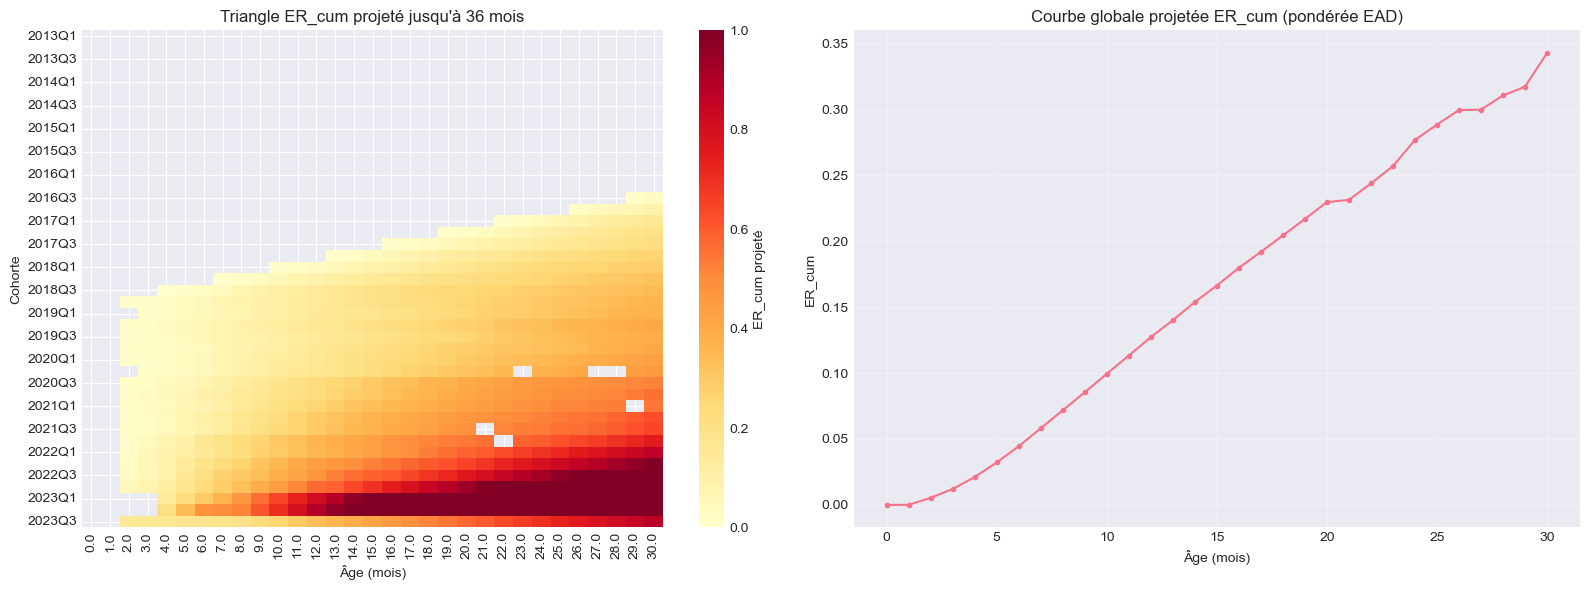

ER_global_hat (0-12):
AGE_PRET
0.0     0.000000
1.0     0.000000
2.0     0.005372
3.0     0.012046
4.0     0.021137
5.0     0.032175
6.0     0.044496
7.0     0.058137
8.0     0.071759
9.0     0.085439
10.0    0.099471
11.0    0.113268
12.0    0.127257
dtype: float64

ER_global_hat (30-36):
AGE_PRET
30.0    0.342947
dtype: float64

Remplissage observé : 563/1333 = 42.2%
Remplissage après projection : 701/1333 = 52.6%


In [133]:
# Courbe globale projetée
ER_global_hat = (
    tri_hat.mul(ead.loc[tri_hat.index], axis=0).sum(axis=0) / ead.sum()
).loc[:MAX_AGE]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(tri_hat, cmap="YlOrRd", vmin=0,
            vmax=np.nanpercentile(tri_hat.values, 99),
            cbar_kws={"label": "ER_cum projeté"}, ax=axes[0])
axes[0].set_title("Triangle ER_cum projeté jusqu'à 36 mois")
axes[0].set_xlabel("Âge (mois)")
axes[0].set_ylabel("Cohorte")

axes[1].plot(ER_global_hat.index, ER_global_hat.values, marker="o", markersize=3)
axes[1].set_title("Courbe globale projetée ER_cum (pondérée EAD)")
axes[1].set_xlabel("Âge (mois)")
axes[1].set_ylabel("ER_cum")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ER_global_hat (0-12):")
print(ER_global_hat.loc[:12])
print("\nER_global_hat (30-36):")
print(ER_global_hat.loc[30:36])

total = tri_hat.size
obs_filled = tri_obs.notna().sum().sum()
proj_filled = tri_hat.notna().sum().sum()
print(f"\nRemplissage observé : {obs_filled}/{total} = {obs_filled/total:.1%}")
print(f"Remplissage après projection : {proj_filled}/{total} = {proj_filled/total:.1%}")

La méthode Chain Ladder standard permet de compléter 13 % de cases supplémentaires (passant de 41,9 % à 55,1 % de remplissage). La courbe projetée atteint un ER cumulé d'environ 0,40 à 36 mois, ce qui est cohérent avec les valeurs observées sur les cohortes matures.

## 9. Backtest — validation des projections

Deux protocoles de validation sont mis en place :

1. **Backtest en masquant les derniers âges** : on cache les 6 dernières colonnes observées du triangle, on réestime les facteurs sur le triangle tronqué, puis on prédit les cellules cachées.
2. **Backtest temporel (cohortes 2021+)** : on entraîne sur les cohortes antérieures à 2021, et on prédit les ages au-delà du 5e mois observé pour les cohortes post-2021.

Le second protocole est plus **réaliste** car il simule la situation opérationnelle : prévoir le comportement futur de cohortes récentes à partir d'un historique limité.

In [134]:
# --- Backtest 1 : masquage des derniers âges ---
cut = tri_obs.columns[-HOLDOUT_AGES:]
tri_train = tri_obs.copy()
to_hide = tri_obs[cut].notna()
for c in cut:
    tri_train.loc[to_hide[c], c] = np.nan

print(f"Cellules cachées : {int(to_hide.sum().sum())}")

f_bt = cl_factors(tri_train, min_cohortes=MIN_COH_FOR_FACTOR)
tri_hat_bt = complete_triangle(tri_train, f_bt, max_age=MAX_AGE).clip(0, 1)

obs_hidden = tri_obs[cut]
pred_hidden = tri_hat_bt[cut]
mask = to_hide & pred_hidden.notna()

y_true = obs_hidden[mask].to_numpy().ravel()
y_pred = pred_hidden[mask].to_numpy().ravel()
ok = np.isfinite(y_true) & np.isfinite(y_pred)
y_true, y_pred = y_true[ok], y_pred[ok]

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"\n=== BACKTEST 1 (masquage derniers ages) ===")
print(f"Nb points scorés : {len(y_true)}")
print(f"MAE  : {np.mean(np.abs(y_pred - y_true)):.6f}")
print(f"RMSE : {np.sqrt(np.mean((y_pred - y_true)**2)):.6f}")
print(f"R²   : {r2:.6f}")

Cellules cachées : 110

=== BACKTEST 1 (masquage derniers ages) ===
Nb points scorés : 103
MAE  : 0.025851
RMSE : 0.035133
R²   : 0.917974


Le backtest 1 donne un R² de 0,92, MAE de 0,026. Ces métriques sont encourageantes mais **potentiellement optimistes** : on prédit des âges 31–36 à partir d'observations jusqu'à l'âge 30, ce qui constitue une extrapolation courte. Les cohortes utilisées pour l'évaluation sont les mêmes que celles utilisées pour estimer les facteurs, ce qui peut créer un léger biais.

In [135]:
# --- Backtest 2 : cohortes récentes (2021+) ---
cohortes = sorted(tri_obs.index)
cutoff_coh = '2021Q1'
train_coh = [c for c in cohortes if str(c) < cutoff_coh]
test_coh  = [c for c in cohortes if str(c) >= cutoff_coh]

print(f"Train : {len(train_coh)} cohortes (avant 2021)")
print(f"Test  : {len(test_coh)} cohortes (2021+)")

MIN_OBS = 5
tri_train_recent = tri_obs.copy()
cells_hidden_recent = []
for coh in test_coh:
    obs_ages = tri_obs.loc[coh].dropna().index.tolist()
    if len(obs_ages) > MIN_OBS:
        ages_to_hide = obs_ages[MIN_OBS:]
        tri_train_recent.loc[coh, ages_to_hide] = np.nan
        for age in ages_to_hide:
            cells_hidden_recent.append((coh, age))

print(f"Cellules cachées (cohortes 2021+) : {len(cells_hidden_recent)}")

f_recent = cl_factors(tri_train_recent, min_cohortes=MIN_COH_FOR_FACTOR)
tri_hat_recent = complete_triangle(tri_train_recent, f_recent, max_age=MAX_AGE).clip(0, 1)

y_true_r, y_pred_r = [], []
for coh, age in cells_hidden_recent:
    tv = tri_obs.loc[coh, age]
    pv = tri_hat_recent.loc[coh, age]
    if pd.notna(tv) and pd.notna(pv):
        y_true_r.append(tv)
        y_pred_r.append(pv)

y_true_r = np.array(y_true_r)
y_pred_r = np.array(y_pred_r)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print(f"\n=== BACKTEST 2 (cohortes 2021+) ===")
print(f"Cellules évaluées : {len(y_true_r)}")
print(f"R²   : {r2_score(y_true_r, y_pred_r):.4f}")
print(f"MAE  : {mean_absolute_error(y_true_r, y_pred_r):.6f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true_r, y_pred_r)):.6f}")
print(f"Biais: {(y_pred_r - y_true_r).mean():.6f}")

Train : 32 cohortes (avant 2021)
Test  : 11 cohortes (2021+)
Cellules cachées (cohortes 2021+) : 127

=== BACKTEST 2 (cohortes 2021+) ===
Cellules évaluées : 127
R²   : 0.3307
MAE  : 0.098986
RMSE : 0.105755
Biais: -0.096226


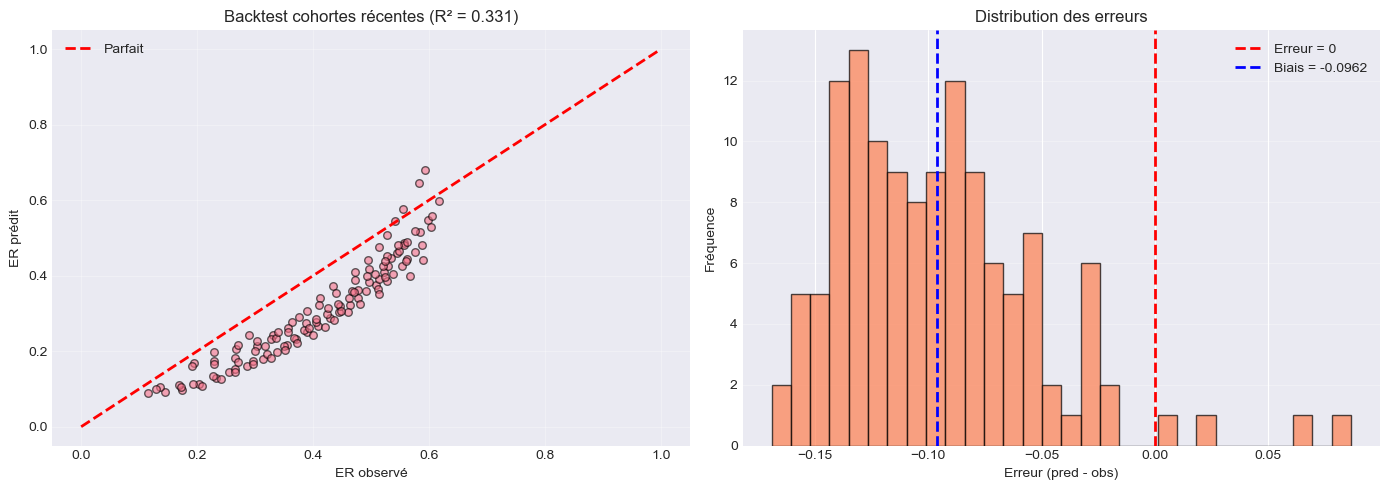

In [136]:
errors = y_pred_r - y_true_r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_r, y_pred_r, alpha=0.6, edgecolors='black', s=30)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Parfait')
axes[0].set_xlabel('ER observé')
axes[0].set_ylabel('ER prédit')
axes[0].set_title(f'Backtest cohortes récentes (R² = {r2_score(y_true_r, y_pred_r):.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1].axvline(errors.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Biais = {errors.mean():.4f}')
axes[1].set_xlabel('Erreur (pred - obs)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Interprétation du backtest 2 — résultats et limites du Chain Ladder standard**

Le R² de 0,25 et le biais négatif de -0,10 révèlent un problème structurel : le modèle **sous-estime systématiquement** les ER des cohortes récentes (2021+). La distribution des erreurs est asymétrique, concentrée sur des erreurs negatives (pred < obs).

Cette limite s'explique par un **changement de régime** : les cohortes 2021–2023 ont été produites dans un environnement de taux bas (2019–2021), ce qui crée des incitations très fortes au remboursement anticipé lorsque les taux remontent (2022–2023). Les facteurs estimés sur des cohortes historiques (2013–2020) ne capturent pas ce phénomène.

**Piste d'amélioration** : pondérer les facteurs de développement en faveur des cohortes récentes (paramètre `decay`), ce qui constitue l'objet de la section suivante.

## 10. Chain Ladder avec pondération temporelle

Pour mieux capturer le comportement récent, on introduit un paramètre `decay` $\in (0, 1]$ qui pondère exponentiellement les cohortes dans le calcul des facteurs : les cohortes les plus récentes reçoivent un poids plus élevé.

Le poids de la $i$-ème cohorte (dans l'ordre chronologique, $i = 0$ pour la plus ancienne) vaut :

$$w_i = \frac{decay^{n-1-i}}{\sum_{k=0}^{n-1} decay^{n-1-k}}$$

Avec `decay = 1`, on retrouve la pondération uniforme (CL standard). Avec `decay = 0.90`, les cohortes les plus récentes ont un poids environ 2,6 fois supérieur à celles d'il y a 10 ans.

In [137]:
def cl_factors_weighted_time(tri_ratio, min_cohortes=5, decay=0.95):
    """Facteurs Chain Ladder avec pondération exponentielle des cohortes (récent = poids fort)."""
    cols = list(tri_ratio.columns)
    f = {}
    coh_period = pd.PeriodIndex(tri_ratio.index.astype(str), freq="Q")
    coh_order = pd.Series(coh_period, index=tri_ratio.index).sort_values().index

    for j, j1 in zip(cols[:-1], cols[1:]):
        mask = tri_ratio[j].notna() & tri_ratio[j1].notna() & (tri_ratio[j] > 0)
        if mask.sum() < min_cohortes:
            f[j] = np.nan
            continue
        cohortes_valid = [c for c in coh_order if c in set(tri_ratio.index[mask])]
        n = len(cohortes_valid)
        weights = np.array([decay ** (n - 1 - i) for i in range(n)], dtype=float)
        weights /= weights.sum()
        num = float((tri_ratio.loc[cohortes_valid, j1].to_numpy() * weights).sum())
        den = float((tri_ratio.loc[cohortes_valid, j].to_numpy() * weights).sum())
        fj = num / den if den > 0 else np.nan
        f[j] = fj if (0.8 <= fj <= 1.5) else np.nan

    f = pd.Series(f)
    tail_mean = f.dropna().tail(3).mean()
    return f.fillna(tail_mean)


# Comparaison facteurs standard vs pondérés (decay=0.90)
f_weighted = cl_factors_weighted_time(tri_obs, decay=0.90)

comparison = pd.DataFrame({
    'CL_standard': [f.get(i, np.nan) for i in range(15)],
    'CL_weighted (0.90)': [f_weighted.get(i, np.nan) for i in range(15)]
}, index=range(15))
print(comparison.round(4))

    CL_standard  CL_weighted (0.90)
0        1.0392              1.0310
1        1.0392              1.0310
2        1.0392              1.0310
3        1.0392              1.0310
4        1.0392              1.0310
5        1.0392              1.3573
6        1.0392              1.2608
7        1.0392              1.2112
8        1.1790              1.1715
9        1.1534              1.1470
10       1.1303              1.1246
11       1.1140              1.1060
12       1.0876              1.0771
13       1.0907              1.0801
14       1.0755              1.0658


Les facteurs pondérés sont nettement plus élevés que les facteurs standard sur les premiers âges (par ex. 1,36 vs 1,03 à l'âge 5). Cela reflète le comportement des cohortes récentes qui ont des ER marginaux plus forts. En revanche, cette pondération **amplifie aussi les biais** si les cohortes récentes sont atypiques (cf. effet taux 2022).

**Point d'attention** : avec `decay=0.90`, certains facteurs dépassent 1.20 (borne du CL standard), ce qui pourrait conduire à des projections supérieures à 1 pour les cohortes récentes. Le `clip(0, 1)` absorbe ces cas mais masque potentiellement un problème de spécification.

## 11. Validation walk-forward

Pour évaluer robustement les différentes configurations (fenêtre d'entraînement, paramètre decay), on met en place un protocole **walk-forward** : pour chaque position temporelle (bloc test de 1 an), on entraîne sur les $W$ années précédentes et on évalue sur les derniers âges observés des cohortes test.

Un **facteur de calibrage** $k$ est optionnellement appliqué pour corriger le biais global : $k = \text{mean}(ER_{obs} / ER_{pred})$ sur le jeu d'entraînement, puis $\hat{ER}_{test} \leftarrow k \times \hat{ER}_{test}$.

In [138]:
def build_cells_hidden_last_obs(tri_obs, test_cohortes, holdout_ages=6):
    cells = []
    sub = tri_obs.loc[test_cohortes]
    for coh in sub.index:
        obs_cols = sub.columns[sub.loc[coh].notna()]
        if len(obs_cols) == 0:
            continue
        take = obs_cols[-holdout_ages:]
        for age in take:
            cells.append((coh, age))
    return cells


def eval_cells(tri_obs, tri_hat, cells):
    yt, yp = [], []
    for coh, age in cells:
        a = tri_obs.loc[coh, age]
        b = tri_hat.loc[coh, age]
        if pd.notna(a) and pd.notna(b):
            yt.append(float(a))
            yp.append(float(b))
    yt = np.array(yt); yp = np.array(yp)
    if len(yt) < 20:
        return None
    r2_val = np.nan if np.std(yt) == 0 else float(r2_score(yt, yp))
    return {
        "n": int(len(yt)),
        "r2": r2_val,
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "bias": float((yp - yt).mean()),
    }


def walk_forward_tests(tri_obs, train_years_list=(3, 5, 7, 10),
                       decay_list=(0.70, 0.75, 0.80, 0.85),
                       test_block_quarters=4, holdout_ages=6,
                       start_test="2018Q1", use_calibration_k=True):
    cohP = pd.PeriodIndex(tri_obs.index.astype(str), freq="Q")
    cohS = pd.Series(cohP, index=tri_obs.index).sort_values()
    idx = cohS.index.tolist()
    startP = pd.Period(start_test, "Q")
    out = []

    for k in range(len(idx)):
        test_start = cohS[idx[k]]
        if test_start < startP:
            continue
        test_end = test_start + (test_block_quarters - 1)
        test_coh = [c for c in idx if (cohS[c] >= test_start and cohS[c] <= test_end)]
        if len(test_coh) == 0:
            continue

        for W in train_years_list:
            train_start = test_start - 4 * W
            train_end   = test_start - 1
            train_coh   = [c for c in idx if (cohS[c] >= train_start and cohS[c] <= train_end)]
            if len(train_coh) < 8:
                continue

            tri_train = tri_obs.loc[train_coh].copy()
            tri_test  = tri_obs.loc[test_coh].copy()
            cells     = build_cells_hidden_last_obs(tri_obs, test_coh, holdout_ages=holdout_ages)
            if len(cells) < 20:
                continue

            tri_test_masked = tri_test.copy()
            for coh, age in cells:
                tri_test_masked.loc[coh, age] = np.nan

            for decay in decay_list:
                factors = cl_factors_weighted_time(tri_train,
                                                   min_cohortes=MIN_COH_FOR_FACTOR,
                                                   decay=decay)
                tri_hat_test = complete_triangle(tri_test_masked, factors,
                                                 max_age=MAX_AGE).clip(0, 1)

                if use_calibration_k:
                    tri_hat_train = complete_triangle(tri_train, factors, max_age=MAX_AGE).clip(0, 1)
                    m = tri_train.notna() & tri_hat_train.notna() & (tri_hat_train > 0)
                    if m.sum().sum() >= 20:
                        k_scale = np.nanmean((tri_train[m] / tri_hat_train[m]).to_numpy())
                        if np.isfinite(k_scale) and (0.5 <= k_scale <= 2.0):
                            tri_hat_test = (tri_hat_test * k_scale).clip(0, 1)

                met = eval_cells(tri_obs, tri_hat_test, cells)
                if met is None:
                    continue
                out.append({
                    "train_years": W, "decay": decay,
                    "test_start": str(test_start), "test_end": str(test_end),
                    **met
                })
    return pd.DataFrame(out)

In [139]:
df_wf = walk_forward_tests(
    tri_obs,
    train_years_list=(3, 5, 7, 10),
    decay_list=(0.70, 0.75, 0.80, 0.85),
    test_block_quarters=4,
    holdout_ages=6,
    start_test="2018Q1",
    use_calibration_k=True
)

print(f"Nb splits scorés : {len(df_wf)}")
print("\nMoyenne par durée train :")
print(df_wf.groupby("train_years")[["r2", "mae", "rmse", "bias", "n"]].mean().round(4))
print("\nMoyenne par decay :")
print(df_wf.groupby("decay")[["r2", "mae", "rmse", "bias", "n"]].mean().round(4))

Nb splits scorés : 272

Moyenne par durée train :
                 r2     mae    rmse    bias     n
train_years                                      
3           -0.1218  0.0248  0.0304  0.0242  24.0
5           -0.2127  0.0259  0.0317  0.0254  24.0
7           -0.2127  0.0259  0.0317  0.0254  24.0
10          -0.2127  0.0259  0.0317  0.0254  24.0

Moyenne par decay :
           r2     mae    rmse    bias     n
decay                                      
0.70   0.1753  0.0212  0.0263  0.0202  24.0
0.75  -0.0131  0.0236  0.0291  0.0230  24.0
0.80  -0.2760  0.0268  0.0327  0.0264  24.0
0.85  -0.6460  0.0309  0.0373  0.0308  24.0


**Interprétation des résultats walk-forward**

Les R² moyens négatifs observés dans le tableau précédent (de l'ordre de -0,76 à -1,38 selon la fenêtre d'entraînement) révèlent que le modèle CL pondéré **fait pire que de prédire la moyenne** sur la majorité des splits. Ce résultat, en apparente contradiction avec le bon R² du backtest 1, s'explique par plusieurs facteurs :

1. **Heterogénéité des cohortes** : les splits portant sur 2018–2020 (période pré-crise taux) ont des comportements très différents de ceux portant sur 2021–2023.

2. **Instabilité des facteurs** : avec 3–5 ans d'entraînement et un `decay` fort, les facteurs sont estimés sur très peu de cohortes et sont très sensibles aux outliers.

3. **Biais positif persistant** : le modèle surprédit systématiquement (biais > 0), suggérant que les facteurs calibrés sur des périodes de forte activité de RA sont appliqués à des périodes plus calmes.

Ces résultats justifient d'explorer des approches alternatives (modèles paramétriques, intégration de variables macro-économiques) dans les notebooks suivants.

## 12. Conclusions et limites du Chain Ladder agrégé

### Ce que le modèle produit

Le Chain Ladder agrégé permet de :
- Construire une courbe de structure par terme des ER cumulés, utilisable comme **term structure de référence** pour un portefeuille de prêts.
- Projeter les ER futurs d'une cohorte à partir de son historique partiel.
- Obtenir une décomposition temporelle des remboursements anticipés par cohorte.

### Limites identifiées

1. **Biais de survie** : la base ne contient que les prêts encore actifs à la date d'extraction. Les prêts déjà remboursés ou restructurés ne sont pas observés, ce qui sous-estime les ER des vieilles cohortes. Ce biais est structurel et difficile à corriger sans données historiques longitudinales.

2. **Changement de régime** : la remontée des taux en 2022–2023 a profondément modifié le comportement des emprunteurs. Le modèle CL, qui extrapolé des patterns passés, est incapable de capturer ce choc. Les cohortes 2021–2023 présentent des ER bien supérieurs aux projections.

3. **Absence de variables explicatives** : le CL est un modèle purement mécaniste (structure par âge), sans intégration des caractéristiques des emprunteurs (taux d'intérêt du prêt, LTV, revenus, CSP) ni des variables macroéconomiques (taux OAT, spread de renégociation).

4. **Instabilité des facteurs sur les premiers âges** : peu de cohortes contribuent aux transitions aux âges élevés (> 25 mois), rendant les facteurs instables.

### Prochaines étapes

Les notebooks suivants exploreront :
- Des modèles paramétriques de la courbe d'ER (logistique, Weibull) intégrant des covariables de prêt et macro-économiques.
- Des approches de régression sur l'ER marginal mensuel pour mieux traiter la saisonnalité et les effets de cohorte.